Accuracy: 97.50%
Confusion Matrix:
 [[32  0]
 [ 1  7]]


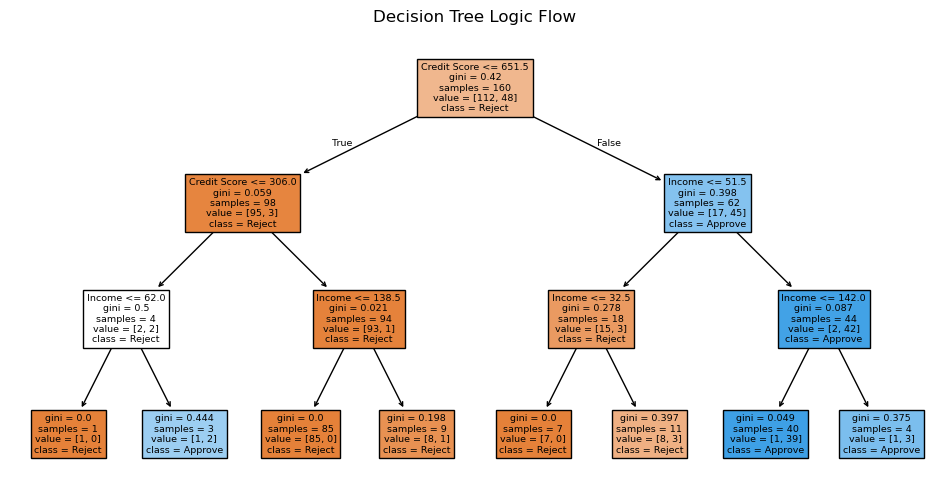

0.975


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score

# 1. THE DATA
# Synthetic Data: High Credit + High Income = Loan Approved
np.random.seed(42)
n_samples = 200
credit_score = np.random.randint(300, 850, size=(n_samples, 1))
income = np.random.randint(20, 150, size=(n_samples, 1)) # in $k
X = np.hstack((credit_score, income))

# The Logic: Score > 650 AND Income > 50k -> Approve (1)
y = np.where((credit_score > 650) & (income > 50), 1, 0).ravel()

# Add some noise (exceptions to the rule) to make it realistic
noise_indices = np.random.choice(n_samples, 10, replace=False)
y[noise_indices] = 1 - y[noise_indices] 

# 2. THE SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. TRAINING (The "Rule-Book" Generator)
# We limit depth to 3 to keep the rules readable
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# 4. EVALUATION
predictions = clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, predictions):.2%}")
print("Confusion Matrix:\n", confusion_matrix(y_test, predictions))

# 5. VISUALIZATION (The unique power of Trees)
plt.figure(figsize=(12, 6))
plot_tree(clf, filled=True, feature_names=['Credit Score', 'Income'], class_names=['Reject', 'Approve'])
plt.title("Decision Tree Logic Flow")
plt.show()
print(clf.score(X_test,y_test))